In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from sklearn import set_config

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.cox_models import Cox_regression, p_values_Cox_regression, plot_coefficients
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
pp = Preprocessor()
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)


<font size="4">Preprocessing</font>

In [31]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_df = pp.elimnation_zeros(df_mRNA_transformed, "Hugo_Symbol")

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)
Max of zeros per row in the dataset: 4575
Avg of zeros per row in the dataset: 2911.273838630807
Median of zeros per row in the dataset: 2866.5
Min of zeros per row in the dataset: 0
After the 0 elimination: 454


<font size="4">ESR1 coefficients and p_values</font>

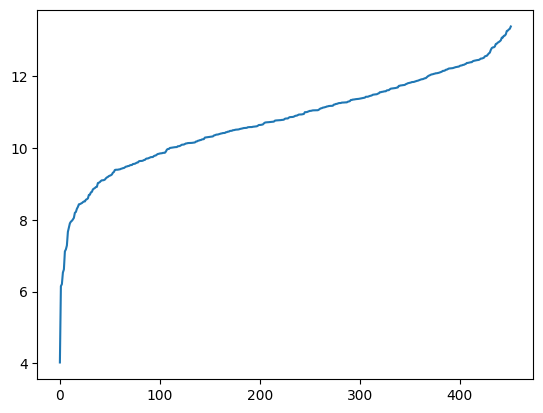

In [81]:
df_ESR1 = pp.gene_to_long(clean_df,"MKI67")
expression = df_ESR1["expression"].values
lsit = list()
for i in expression:
    lsit.append(i)


lsit.sort()


plt.plot(np.log2(lsit)) # plotting by columns
plt.show()

In [85]:
df_ESR1_merged = df_ESR1.merge(df_clinical_keep, on="Sample ID", how="inner")
status = df_ESR1_merged["Overall Survival Status"].astype(str).str.strip()
df_ESR1_merged["event"] = status.str.contains("DECEASED", na=False) 
df_ESR1_merged = df_ESR1_merged.dropna(subset=["Overall Survival (Months)"])
log_2 = [np.log(x + 1) for x in df_ESR1_merged["expression"] + 1]
#X_ESR1 = np.log2(df_ESR1_merged[["expression"]] + 1)
Y_surv_ESR1 = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_ESR1_merged
)

In [86]:
X_train_ESR1, X_test_ESR1, Y_train_ESR1, Y_test_ESR1 = train_test_split(
    log_2, Y_surv_ESR1, train_size=0.80, test_size=0.20, random_state=42
)


In [87]:
betas_ESR1, chp_predict_ESR1, survival_curve_ESR1, risk_curve_ESR1 = Cox_regression(X_train_ESR1, Y_train_ESR1, X_test_ESR1)

ValueError: Expected 2D array, got 1D array instead:
array=[6.40944106 7.03250245 8.37570654 7.0980784  8.54881495 8.96750468
 6.45772258 7.88961365 6.78641408 8.89101912 8.53814388 7.66246782
 7.88511481 7.20938345 7.937785   5.70387514 6.51490615 8.08068837
 7.02863423 9.09814019 7.06012961 6.65208118 6.15149065 8.38480211
 8.23196267 5.86503956 8.57523079 7.96891711 8.75856576 8.14653001
 6.57410131 8.70025597 9.2205575  8.42790539 8.94072998 8.31680396
 6.624345   7.42251487 7.34636202 6.13662602 7.4077926  8.2714085
 7.14426045 6.58566877 8.08232993 6.32553891 8.26002571 7.02087001
 7.44239893 7.65952404 7.62402965 9.01153338 7.37846403 8.02822511
 6.37686197 7.31914626 7.93058549 7.62640304 7.74661864 6.83040101
 5.90442572 7.94195455 6.68423078 7.15008401 8.00997538 6.54806723
 7.9223654  5.48566958 8.09185089 6.18162488 7.07658287 7.87859957
 6.60543553 8.712367   7.98842234 8.47159862 8.20815395 6.82212026
 5.51712955 4.94983449 7.64238576 5.80056581 8.62290266 8.07842571
 7.7

In [67]:
print(betas_ESR1)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression     0.000013     0.000013     0.000013     0.000013     0.000013   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression     0.000013     0.000013     0.000013     0.000013     0.000013   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...     0.000013     0.000013     0.000013     0.000013   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression     0.000013     0.000013     0.000013     0.000013     0.000013   

alpha       10000.00000  
expression     0.000013  

[1 rows x 50 columns]


In [68]:
# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

#Sorteasa normalizas, (0-100)

lsit = list()
for i in chp_predict_ESR1:
    lsit.append(i)

lsit.sort()
exp_ = np.exp(lsit)



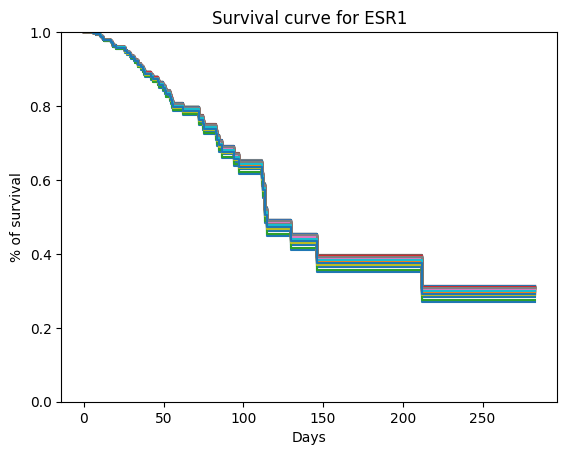

In [69]:

for fn in survival_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

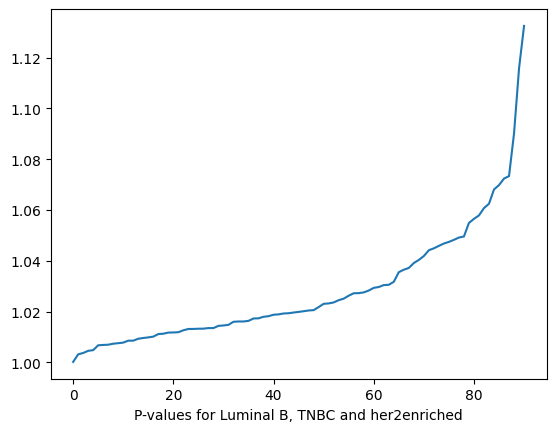

In [70]:
plt.plot(exp_) # plotting by columns
plt.xlabel("P-values for Luminal B, TNBC and her2enriched")
plt.show()

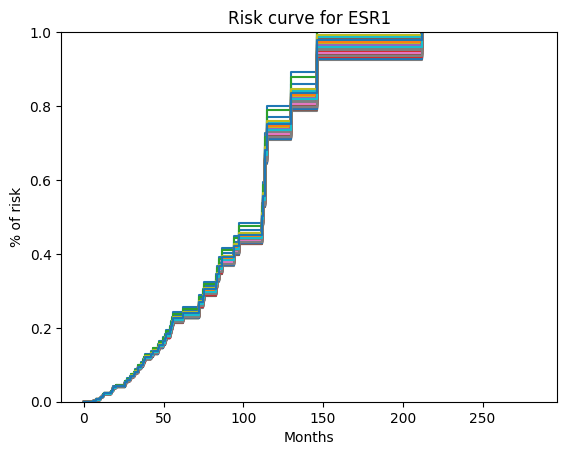

In [71]:
for fn in risk_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for ESR1")
plt.xlabel("Months")
plt.ylim(0, 1)
plt.ylabel("% of risk")
plt.show()

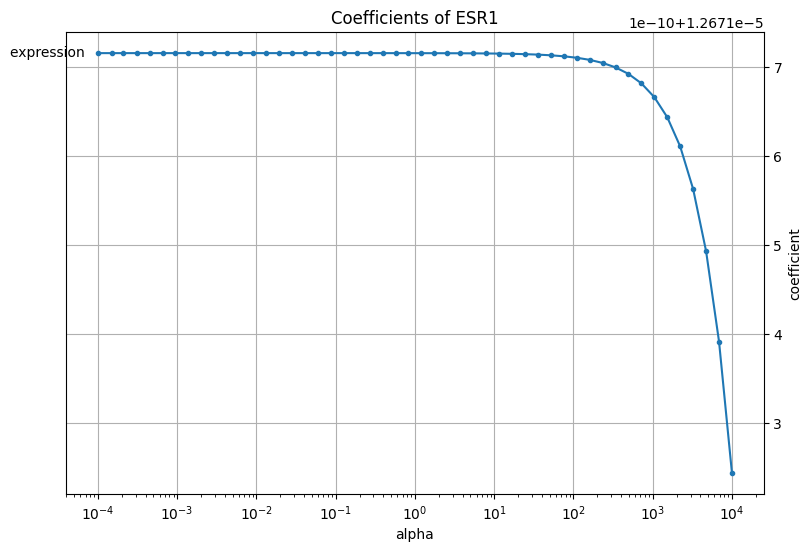

In [72]:
plot_coefficients(betas_ESR1, n_highlight=5, title="Coefficients of ESR1")

In [13]:
"""cox_lasso.fit(X_train_ESR1, X_test_ESR1)
coefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))
plot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")
cox_lasso.predict(X_test)
"""

'cox_lasso.fit(X_train_ESR1, X_test_ESR1)\ncoefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))\nplot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")\ncox_lasso.predict(X_test)\n'

In [73]:
df_life_line_ESR1 = df_ESR1_merged[["expression", "event", "Overall Survival (Months)"]]

In [74]:
p_values_Cox_regression(df_life_line_ESR1,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.79 = No significativo

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,0.000036,1.000036,0.000059,-0.000078,0.000151,0.999922,1.000151,0.0,0.621734,0.534117,0.904773


<font size="4">AURKA coefficients and p_values</font>

In [33]:
df_AURKA = pp.gene_to_long(clean_df, "AURKA")

In [34]:
df_AURKA_merged = df_AURKA.merge(df_clinical_keep, on="Sample ID", how="inner")
status = df_AURKA_merged["Overall Survival Status"].astype(str).str.strip()
df_AURKA_merged["event"] = status.str.contains("DECEASED", na=False) 
df_AURKA_merged = df_AURKA_merged.dropna(subset=["Overall Survival (Months)"])
X_AURKA = df_AURKA_merged[["expression"]]
Y_surv_AURKA = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_AURKA_merged
)

In [35]:
X_train_AURKA, X_test_AURKA, Y_train_AURKA, Y_test_AURKA = train_test_split(
    X_AURKA, Y_surv_AURKA, train_size=0.80, test_size=0.20, random_state=42
)


In [36]:
betas_AURKA, chp_predict_AURKA, survival_curve_AURKA, risk_curve_AURKA = Cox_regression(X_train_AURKA, Y_train_AURKA, X_test_AURKA)

In [37]:
print(betas_AURKA)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       10000.00000  
expression    -0.000002  

[1 rows x 50 columns]


In [40]:
print(chp_predict_AURKA)

# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

lsit = list()
for i in chp_predict_AURKA:
    lsit.append(i)

lsit.sort()

lsit_np = np.exp(lsit)
lsit_np


[-0.00045987 -0.0004478  -0.00019214 -0.00607356 -0.00084914 -0.00040606
 -0.00073634 -0.00205469 -0.00098431 -0.00238117 -0.00026114 -0.00180553
 -0.00394049 -0.00213995 -0.00066283 -0.00053252 -0.00019059 -0.00076849
 -0.00075041 -0.00027709 -0.0012484  -0.00022339 -0.00096148 -0.00077469
 -0.00082735 -0.01061253 -0.00158266 -0.00035362 -0.00029002 -0.00075467
 -0.00056744 -0.00042991 -0.00034457 -0.00030638 -0.00033971 -0.00047915
 -0.00153606 -0.00072167 -0.0002831  -0.00119987 -0.00162013 -0.00034287
 -0.00021992 -0.0003489  -0.00100304 -0.00121767 -0.00051698 -0.00021624
 -0.00212328 -0.00028243 -0.0009641  -0.00115347 -0.00042838 -0.00044249
 -0.00030309 -0.00020911 -0.00144787 -0.00160348 -0.00247449 -0.00042643
 -0.00018601 -0.00070478 -0.00109137 -0.00093831 -0.00049647 -0.00167278
 -0.00063754 -0.00322842 -0.00106687 -0.00073187 -0.00151405 -0.00147096
 -0.00078492 -0.00075083 -0.00100438 -0.00044379 -0.00027774 -0.00042804
 -0.00251505 -0.00287978 -0.00436221 -0.00310464 -0

array([0.98944358, 0.99394485, 0.99564729, 0.99606727, 0.99677679,
       0.99690017, 0.99712436, 0.99718048, 0.99738486, 0.99748811,
       0.99751242, 0.99752857, 0.99762166, 0.99786234, 0.99787897,
       0.99794742, 0.9981961 , 0.99827602, 0.99832862, 0.99838118,
       0.99839781, 0.9984186 , 0.99846512, 0.9984871 , 0.99853012,
       0.99855318, 0.99875238, 0.99878308, 0.99880085, 0.99884719,
       0.99890923, 0.9989337 , 0.99899612, 0.99899746, 0.99901618,
       0.99903637, 0.99903898, 0.99906213, 0.99915122, 0.999173  ,
       0.99921539, 0.99922561, 0.99923181, 0.99924562, 0.99924945,
       0.99924987, 0.99926393, 0.99926839, 0.99927859, 0.99928423,
       0.99929546, 0.99933739, 0.99936266, 0.99941501, 0.99943272,
       0.99946762, 0.99948316, 0.99950365, 0.99952097, 0.99954024,
       0.9995523 , 0.99955631, 0.99955761, 0.99957019, 0.99957171,
       0.99957205, 0.99957366, 0.99959403, 0.99962172, 0.99964644,
       0.99964645, 0.99965116, 0.99965549, 0.99965719, 0.99966

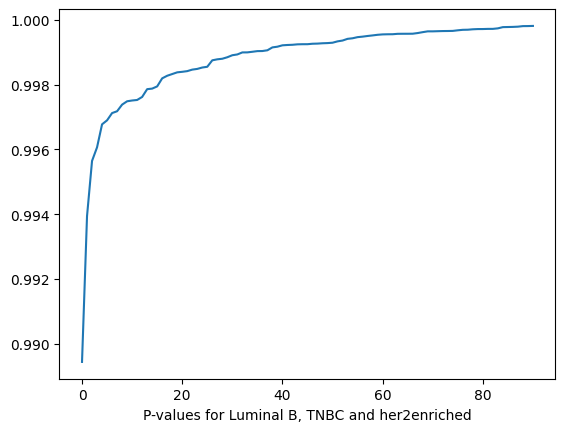

In [41]:
plt.plot(lsit_np) # plotting by columns
plt.xlabel("P-values for Luminal B, TNBC and her2enriched")
plt.show()

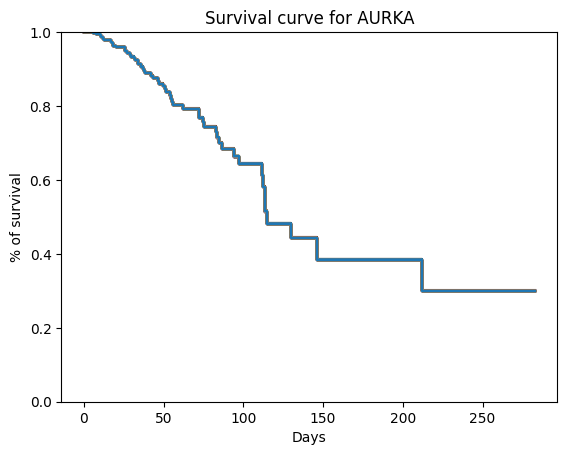

In [22]:
for fn in survival_curve_AURKA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for AURKA")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

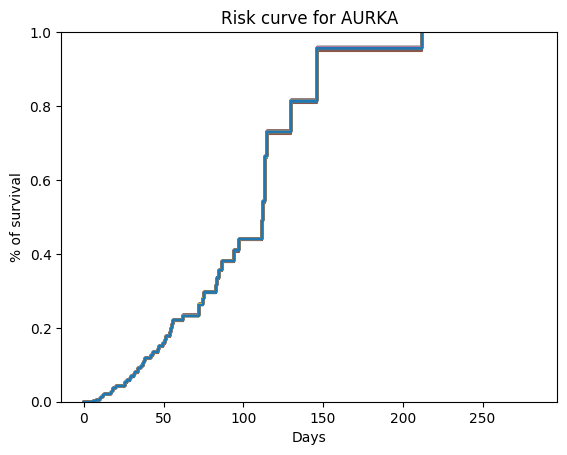

In [23]:
for fn in risk_curve_AURKA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for AURKA")
plt.ylim(0, 1)
plt.xlabel("Days")
plt.ylabel("% of survival")
plt.show()

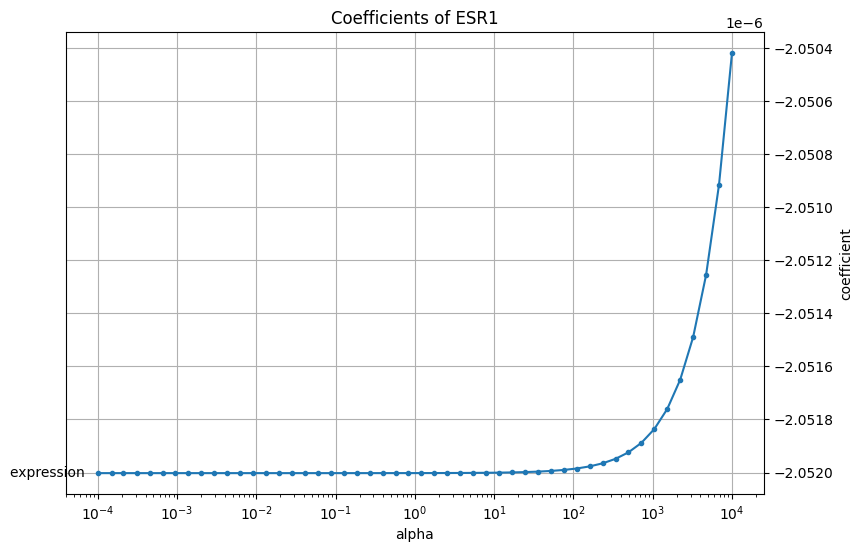

In [24]:
plot_coefficients(betas_AURKA, n_highlight=5, title="Coefficients of ESR1")

In [25]:
df_life_line_AURKA = df_AURKA_merged[["expression", "event", "Overall Survival (Months)"]]

In [26]:
p_values_Cox_regression(df_life_line_AURKA,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.61 = No significativo

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,0.000123,1.000123,0.000247,-0.000362,0.000607,0.999638,1.000607,0.0,0.495879,0.61998,0.689706


<font size="4">Luminal A betas and p_values</font>

In [40]:
pp = Preprocessor()
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
df_merged = pp.merge_datasets(df_clinical_keep, df_mRNA_transformed)

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [41]:
expressions_genes_cols = df_merged.iloc[1:20441].sample(650, axis="columns")
cols = ["Tumor-Cancer", "Overall Survival Status", "Overall Survival (Months)"] + list(expressions_genes_cols)

comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    cols
]

In [42]:
comparation_df = pp.elimnation_zeros(comparation_df, "Tumor-Cancer")

Max of zeros per row in the dataset: 519
Avg of zeros per row in the dataset: 84.71472392638037
Median of zeros per row in the dataset: 0.0
Min of zeros per row in the dataset: 0
After the 0 elimination: 510


In [43]:
luminal_A_df = comparation_df[comparation_df["Tumor-Cancer"] == "Luminal A"]
status = luminal_A_df["Overall Survival Status"].astype(str).str.strip()
luminal_A_df["event"] = status.str.contains("DECEASED", na=False) 
luminal_A_df = luminal_A_df.dropna(subset=["Overall Survival (Months)"])
X_LUMINAL_A = luminal_A_df.iloc[:, 3:-1]
Y_surv_LUMINAL_A = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=luminal_A_df
)

In [44]:

X_train_LuminalA, X_test_LuminalA,Y_train_LuminalA,Y_test_LuminalA = train_test_split(
    X_LUMINAL_A, Y_surv_LUMINAL_A, train_size=0.80, test_size=0.20, random_state=42
)
    

In [45]:
#Need CPU power 
betas_LuminalA, chp_predict_LuminalA, survival_curve_LuminalA, risk_curve_LuminalA = Cox_regression(X_train_LuminalA, Y_train_LuminalA, X_test_LuminalA)

TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [32]:
for fn in survival_curve_LuminalA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

NameError: name 'survival_curve_LuminalA' is not defined

In [46]:
for fn in risk_curve_LuminalA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for Luminal A")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

NameError: name 'risk_curve_LuminalA' is not defined

In [47]:
expressions_luminal_A = luminal_A_df.iloc[:, 3:-1]

In [48]:
p_values_luminalA = []
for i, sample in enumerate(expressions_luminal_A.columns):
    df_life_line_sample = luminal_A_df[
        [sample, "event", "Overall Survival (Months)"]
    ]
    p_values_luminalA.append(p_values_Cox_regression(df_life_line_sample,event_col="event", duration_col="Overall Survival (Months)"))

    if i > 50:
        break 

In [49]:
df_final_luminal_A = pd.concat(p_values_luminalA)

df_final_luminal_A[["coef","exp(coef)", "exp(coef)","z", "p"]]

array_luminal_a = np.asarray(df_final_luminal_A["p"])


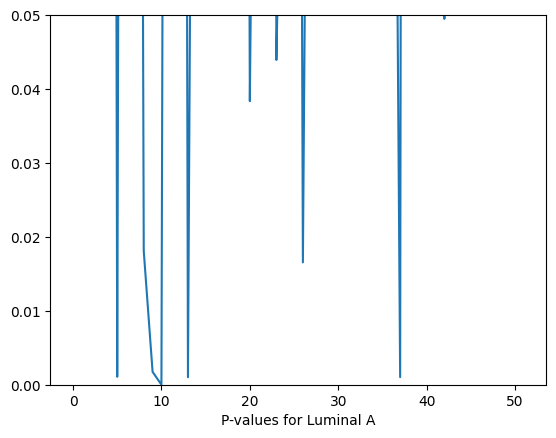

In [51]:
plt.plot(array_luminal_a) # plotting by columns
plt.xlabel("P-values for Luminal A")
plt.ylim(0.00, 0.05)
plt.show()

<font size="4">Luminal B, TNBC, Her-Enriched2 betas and p_values</font>

In [38]:
diff_subtypes_df = comparation_df[comparation_df["Tumor-Cancer"] != "Luminal A"]
status = diff_subtypes_df["Overall Survival Status"].astype(str).str.strip()
diff_subtypes_df["event"] = status.str.contains("DECEASED", na=False) 
diff_subtypes_df = diff_subtypes_df.dropna(subset=["Overall Survival (Months)"])
X_diff_subtypes = diff_subtypes_df.iloc[:, 3:-1]
Y_surv_subtypes = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=diff_subtypes_df
)

In [39]:

X_train_subtypes, X_test_subtypes,Y_train_subtypes,Y_test_subtypes = train_test_split(
    X_diff_subtypes, Y_surv_subtypes, train_size=0.80, test_size=0.20, random_state=42
)

In [ ]:
#Need CPU power
betas_subtypes, chp_predict_subtypes, survival_curve_subtypes, risk_curve_subtypes = Cox_regression(X_train_subtypes, Y_train_subtypes, X_test_subtypes)

KeyboardInterrupt: 

In [ ]:
for fn in survival_curve_subtypes:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for Luminal B, TNBC, HerEnriched2")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

In [ ]:
for fn in risk_curve_subtypes:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for Luminal B, TNBC, HerEnriched2")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

In [41]:
expressions_not_luminalA = diff_subtypes_df.iloc[:, 3:-1]

In [42]:
p_values_not_luminalA = []
for i, sample in enumerate(expressions_not_luminalA.columns):
    df_line_sample_not_luminalA = diff_subtypes_df[
        [sample, "event", "Overall Survival (Months)"]
    ]
    
    p_values_not_luminalA.append(p_values_Cox_regression(df_line_sample_not_luminalA, event_col="event", duration_col="Overall Survival (Months)"))
    
    if i >= 50:
        break
    

In [43]:
df_final_not_luminal_A = pd.concat(p_values_not_luminalA)

df_final_not_luminal_A[["coef","exp(coef)", "exp(coef)","z", "p"]]

p_values = df_final_not_luminal_A["p"]

array_p_values = np.asarray(p_values)

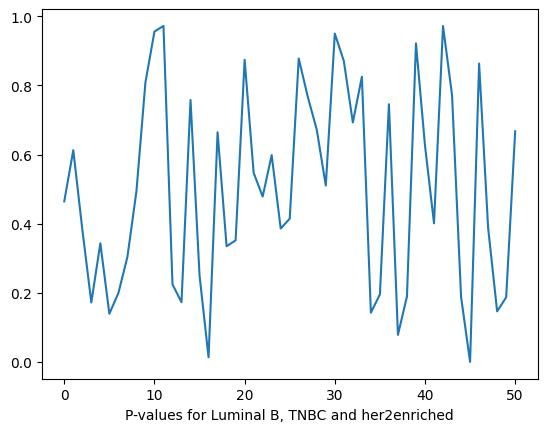

In [45]:
plt.plot(array_p_values) # plotting by columns
plt.xlabel("P-values for Luminal B, TNBC and her2enriched")
plt.show()